In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn nltk gensim

You should consider upgrading via the '/Users/dibbi/myenv/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.datasets import fetch_20newsgroups

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

In [3]:
## Loading the dataset
news = fetch_20newsgroups(subset='all')

## converting dataset to dataframe
df = pd.DataFrame({
    'text': news.data,
    'target': news.target
})


In [5]:
# aadding category names

df['category'] = df['target'].apply(lambda x: news.target_names[x])

In [7]:
# First 5 rows
df.head()

,text,target,category
0,From: Mamatha Devineni Ratnam <mr47+@andrew.cm...,10,rec.sport.hockey
1,From: mblawson@midway.ecn.uoknor.edu (Matthew ...,3,comp.sys.ibm.pc.hardware
2,From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...,17,talk.politics.mideast
3,From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...,3,comp.sys.ibm.pc.hardware
4,From: Alexander Samuel McDiarmid <am2o+@andrew...,4,comp.sys.mac.hardware


In [8]:
# Check dataset shape
df.shape

(18846, 3)

In [9]:
# Check data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18846 entries, 0 to 18845
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      18846 non-null  object
 1   target    18846 non-null  int64 
 2   category  18846 non-null  object
dtypes: int64(1), object(2)
memory usage: 441.8+ KB


In [10]:
# Checking any null values
df.isnull().sum()

text        0
target      0
category    0
dtype: int64

In [11]:
# Checking number of categories
df['category'].nunique()

20

In [12]:
# Category Distribution
df['category'].value_counts()

category
rec.sport.hockey            999
soc.religion.christian      997
rec.motorcycles             996
rec.sport.baseball          994
sci.crypt                   991
rec.autos                   990
sci.med                     990
comp.windows.x              988
sci.space                   987
comp.os.ms-windows.misc     985
sci.electronics             984
comp.sys.ibm.pc.hardware    982
misc.forsale                975
comp.graphics               973
comp.sys.mac.hardware       963
talk.politics.mideast       940
talk.politics.guns          910
alt.atheism                 799
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64

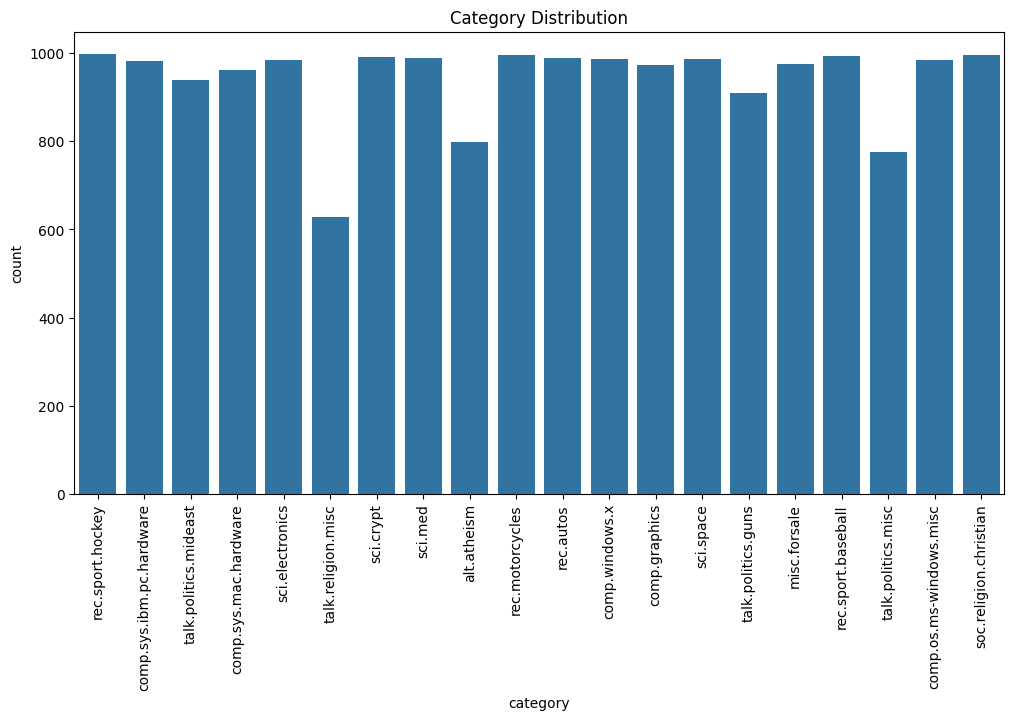

In [13]:
# Category distribution plot
plt.figure(figsize=(12,6))
sns.countplot(x='category', data=df)
plt.xticks(rotation=90)
plt.title("Category Distribution")
plt.show()

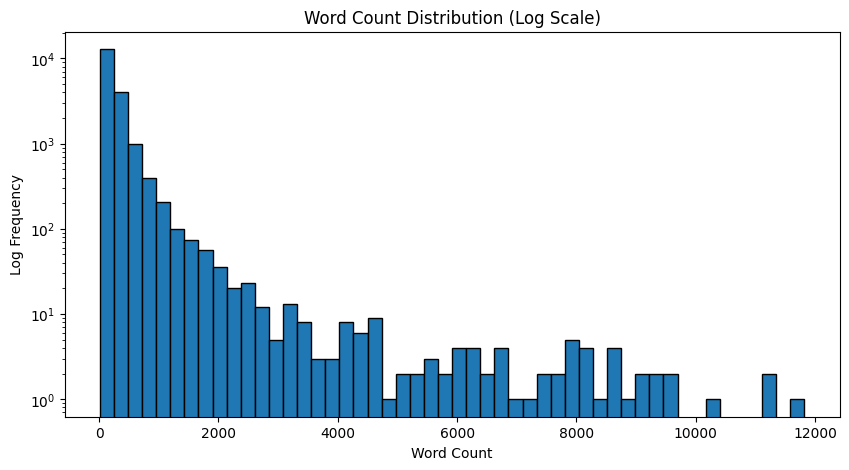

In [14]:
# Text length analysis
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))

plt.hist(
    df['word_count'],
    bins=50,
    edgecolor='black',   # adds border
    linewidth=1          # thickness of border
)

plt.yscale('log')

plt.title("Word Count Distribution (Log Scale)")
plt.xlabel("Word Count")
plt.ylabel("Log Frequency")

plt.show()

In [15]:
# Most frequent words(before cleaning)
# Create vectorizer
vectorizer = CountVectorizer(stop_words='english', max_features=20)

# Fit and transform
X = vectorizer.fit_transform(df['text'])

# Get words
words = vectorizer.get_feature_names_out()

# Get counts
counts = X.toarray().sum(axis=0)

# Create DataFrame
word_freq = pd.DataFrame({'word': words, 'count': counts})

# Sort values
word_freq = word_freq.sort_values(by='count', ascending=False)

word_freq

,word,count
1,ax,62416
5,edu,35703
15,subject,20379
2,com,20223
10,lines,19669
12,organization,18709
19,writes,13344
0,article,12275
4,don,9963
9,like,9697


/var/folders/_7/nxbnpy_n2xzddy498z21r2vw0000gn/T/ipykernel_7596/3311352308.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=word_freq, palette='viridis')


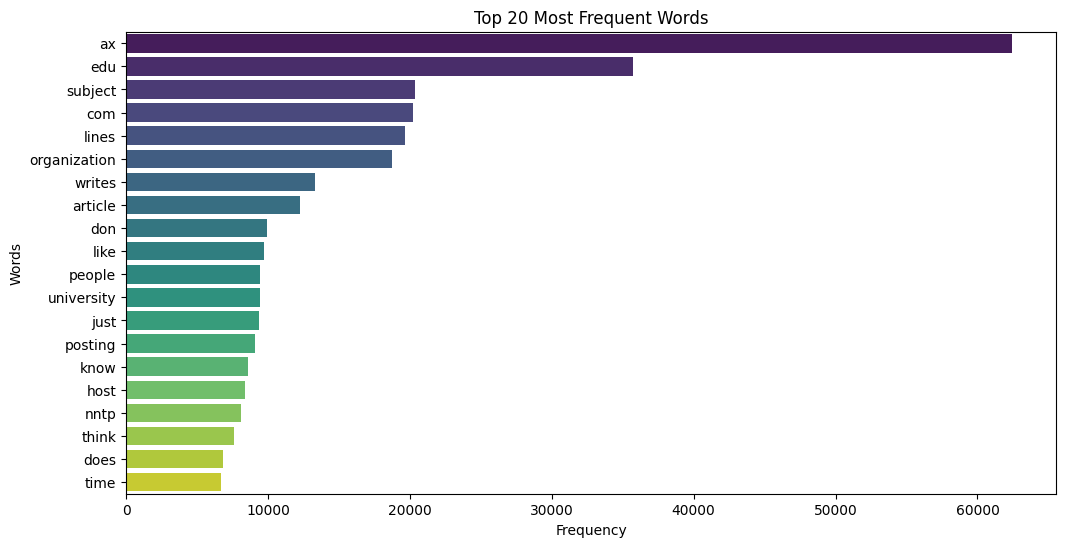

In [16]:
# Plotting most frequent words on graph (before cleaning)

plt.figure(figsize=(12,6))

sns.barplot(x='count', y='word', data=word_freq, palette='viridis')

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

In [17]:
# Downloading NLP resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/dibbi/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /Users/dibbi/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /Users/dibbi/nltk_data...


True

In [18]:
# Text cleaning function
# Initialize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove numbers & special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # 3. Tokenization (split into words)
    words = word_tokenize(text)

    cleaned_words = []

    # 4. Remove stopwords + short words + apply lemmatization
    for word in words:
        if word not in stop_words and len(word) > 2:

            # Only Lemmatization
            word = lemmatizer.lemmatize(word)

            cleaned_words.append(word)

    # 5. Join words back into sentence
    return " ".join(cleaned_words)

In [19]:
# Importing some more nesscary libraries

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/dibbi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/dibbi/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /Users/dibbi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/dibbi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [20]:
# Apply cleaning

df['clean_text'] = df['text'].apply(clean_text)

In [21]:
# Removing meta data

import re

def remove_metadata(text):
    # Remove email headers and technical fields
    text = re.sub(r'\S+@\S+', '', text)   # remove emails
    text = re.sub(r'http\S+', '', text)   # remove URLs
    text = re.sub(r'\b\w*(edu|com|org)\b', '', text)  # remove domains
    text = re.sub(r'(subject|organization|lines|keywords|nntp|posting|host)', '', text)

    return text

df['clean_text'] = df['clean_text'].apply(remove_metadata)

In [22]:
# Removing some garbage words

def remove_noise_words(text):
    words = text.split()
    words = [w for w in words if len(w) > 3]  # remACove very short/noisy words
    return " ".join(words)

df['clean_text'] = df['clean_text'].apply(remove_noise_words)

In [23]:
# Checking cleaned text

df[['text', 'clean_text']].head()

,text,clean_text
0,From: Mamatha Devineni Ratnam <mr47+@andrew.cm...,mamatha devineni ratnam andrew reaction post o...
1,From: mblawson@midway.ecn.uoknor.edu (Matthew ...,mblawson midway uoknor matthew lawson high per...
2,From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...,hilmi hilmi eren armenia could shoot turkish p...
3,From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...,guyd austin dawson scsi detach originator guyd...
4,From: Alexander Samuel McDiarmid <am2o+@andrew...,alexander samuel mcdiarmid andrew driver sopho...


In [24]:
# Frequent words after cleaning

vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(df['clean_text'])

from collections import Counter

# Combine all cleaned text
all_words_clean = " ".join(df['clean_text']).split()

# Get top 20 frequent words
common_words_clean = Counter(all_words_clean).most_common(20)

# Convert to DataFrame (TABLE)
freq_table = pd.DataFrame(common_words_clean, columns=['Word', 'Frequency'])

freq_table

,Word,Frequency
0,line,21865
1,would,14830
2,writes,13344
3,article,12696
4,like,9805
5,people,9565
6,university,9522
7,know,9288
8,time,8231
9,think,7830


/var/folders/_7/nxbnpy_n2xzddy498z21r2vw0000gn/T/ipykernel_7596/3892285137.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


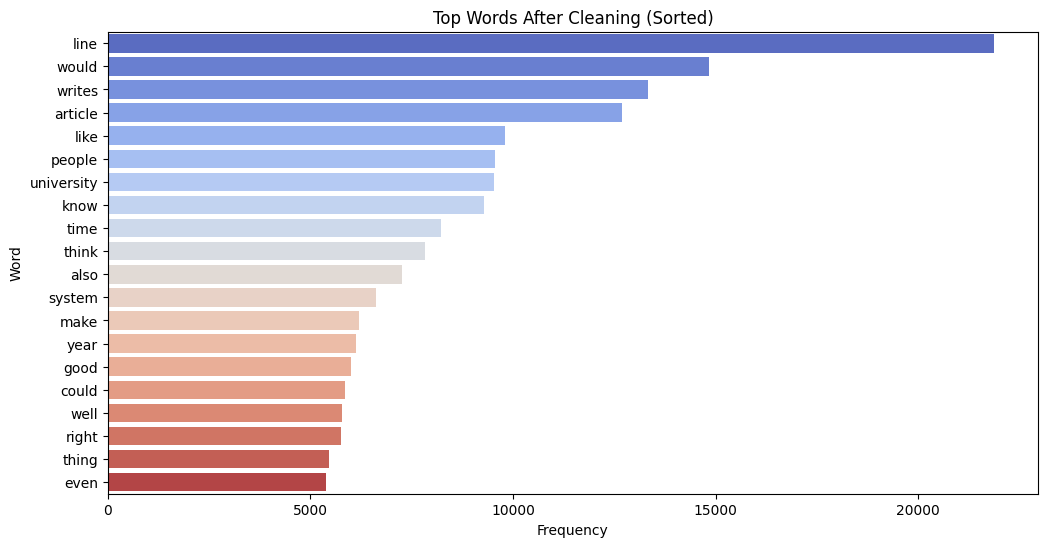

In [25]:
# Plotting frequent words

plt.figure(figsize=(12,6))

sns.barplot(
    x=freq_table['Frequency'],
    y=freq_table['Word'],
    order=freq_table.sort_values('Frequency', ascending=False)['Word'],
    palette='coolwarm'
)

plt.title("Top Words After Cleaning (Sorted)")
plt.show()

In [26]:
# Importing some libraries

from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Find most appearing word in each category

category_list = []
word_list = []
freq_list = []

# Loop through each category
for cat in df['category'].unique():

    # Get all cleaned text for that category
    texts = df[df['category'] == cat]['clean_text']

    # Combine all words into one list
    words = []
    for sentence in texts:
        words.extend(sentence.split())

    # Count frequency of each word
    counter = Counter(words)

    # Get most frequent word
    most_common_word, freq = counter.most_common(1)[0]

    # Store results
    category_list.append(cat)
    word_list.append(most_common_word)
    freq_list.append(freq)

In [28]:
# Creating the resultant dataframe

result_df = pd.DataFrame({
    'Category': category_list,
    'Word': word_list,
    'Frequency': freq_list
})

print(result_df)

                    Category       Word  Frequency
0           rec.sport.hockey       game       1718
1   comp.sys.ibm.pc.hardware      drive       1406
2      talk.politics.mideast   armenian       2112
3      comp.sys.mac.hardware       line       1090
4            sci.electronics       line       1285
5         talk.religion.misc       line        696
6                  sci.crypt       line       1203
7                    sci.med       line       1043
8                alt.atheism     writes        903
9            rec.motorcycles       bike       1088
10                 rec.autos       line       1073
11            comp.windows.x     window       1798
12             comp.graphics      image       1885
13                 sci.space      space       1995
14        talk.politics.guns      would       1219
15              misc.forsale       line       1060
16        rec.sport.baseball       game       1125
17        talk.politics.misc     people       1202
18   comp.os.ms-windows.misc   

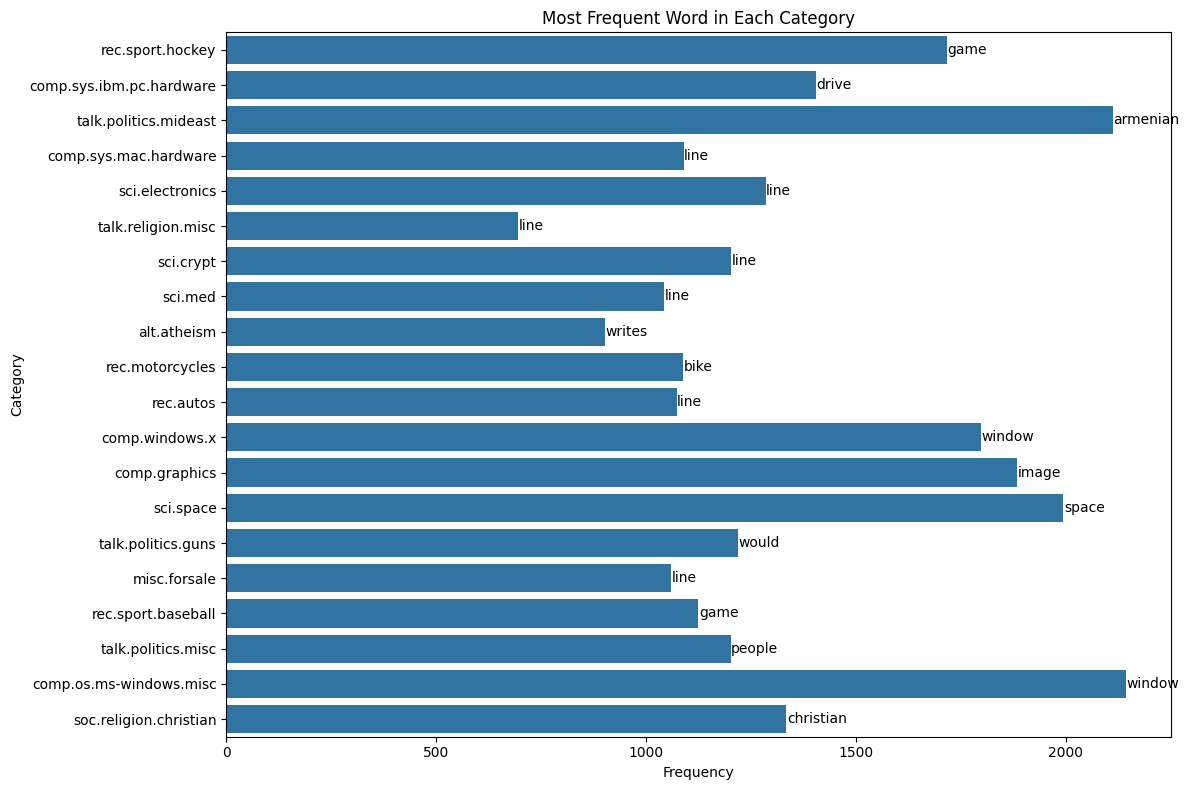

In [29]:
# Plotting Most appearing word in Each category on the GRAPH

plt.figure(figsize=(12,8))

ax = sns.barplot(
    y='Category',
    x='Frequency',
    data=result_df
)

# Add word labels at end of each bar
for i in range(len(result_df)):
    ax.text(
        result_df['Frequency'][i] + 1,
        i,
        result_df['Word'][i],
        va='center'
    )

plt.title("Most Frequent Word in Each Category")
plt.xlabel("Frequency")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [30]:
## SHOWING STOP WORD REMOVAL AND LEMMATIZATION ON A SAMPLE DOCUMENT

from sklearn.datasets import fetch_20newsgroups
import pandas as pd

# Selecting a sample document
sample_text = df['text'].iloc[0]

# Tokenize
tokens = word_tokenize(sample_text)

# Removing the stopwords
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]

# Printing the results
print("ORIGINAL TEXT \n")
print(sample_text[:500])

print("\nTOKENS BEFORE STOPWORD REMOVAL \n")
print(tokens[:50])

print("\nTOKENS AFTER STOPWORD REMOVAL \n")
print(filtered_tokens[:50])


ORIGINAL TEXT 

From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>
Subject: Pens fans reactions
Organization: Post Office, Carnegie Mellon, Pittsburgh, PA
Lines: 12
NNTP-Posting-Host: po4.andrew.cmu.edu



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killin

TOKENS BEFORE STOPWORD REMOVAL 

['From', ':', 'Mamatha', 'Devineni', 'Ratnam', '<', 'mr47+', '@', 'andrew.cmu.edu', '>', 'Subject', ':', 'Pens', 'fans', 'reactions', 'Organization', ':', 'Post', 'Office', ',', 'Carnegie', 'Mellon', ',', 'Pittsburgh', ',', 'PA', 'Lines', ':', '12', 'NNTP-Posting-Host', ':', 'po4.andrew.cmu.edu', 'I', 'am', 'sure', 'some', 'bashers', 'of', 'Pens', 'fans', 'are', 'pretty', 'confused', 'about', 'the', 'lack', 'of', 'any', 'kind', 'of']

TOKENS AFT

In [31]:
## SHOWING LEMMATIZATION

# Importing libraries
import nltk
import re
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# Downloading resources

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package punkt to /Users/dibbi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/dibbi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/dibbi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/dibbi/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [32]:
# POS (Part of speech) tag conversion

# POS conversion function
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [33]:
# LEMMATZATION function on a sample text

# Initialize
lemmatizer = WordNetLemmatizer()

# Sample text
sample_text = df['text'].iloc[0]

# Clean text
sample_text = re.sub(r'[^a-zA-Z]', ' ', sample_text)
sample_text = sample_text.lower()

# Tokenize
tokens = word_tokenize(sample_text)

# Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in tokens if w not in stop_words]

# POS tagging
pos_tags = pos_tag(filtered_tokens)

# Lemmatization with POS
lemmatized_words = [
    lemmatizer.lemmatize(word, get_wordnet_pos(tag))
    for word, tag in pos_tags
]

# Output
print("BEFORE:\n", filtered_tokens[:50])
print("\nAFTER:\n", lemmatized_words[:50])

BEFORE:
 ['mamatha', 'devineni', 'ratnam', 'mr', 'andrew', 'cmu', 'edu', 'subject', 'pens', 'fans', 'reactions', 'organization', 'post', 'office', 'carnegie', 'mellon', 'pittsburgh', 'pa', 'lines', 'nntp', 'posting', 'host', 'po', 'andrew', 'cmu', 'edu', 'sure', 'bashers', 'pens', 'fans', 'pretty', 'confused', 'lack', 'kind', 'posts', 'recent', 'pens', 'massacre', 'devils', 'actually', 'bit', 'puzzled', 'bit', 'relieved', 'however', 'going', 'put', 'end', 'non', 'pittsburghers']

AFTER:
 ['mamatha', 'devineni', 'ratnam', 'mr', 'andrew', 'cmu', 'edu', 'subject', 'pen', 'fan', 'reaction', 'organization', 'post', 'office', 'carnegie', 'mellon', 'pittsburgh', 'pa', 'line', 'nntp', 'post', 'host', 'po', 'andrew', 'cmu', 'edu', 'sure', 'bashers', 'pen', 'fan', 'pretty', 'confused', 'lack', 'kind', 'post', 'recent', 'pen', 'massacre', 'devil', 'actually', 'bit', 'puzzled', 'bit', 'relieve', 'however', 'go', 'put', 'end', 'non', 'pittsburghers']


In [34]:
### TF-IDF ( TERM FREQUENCY - INVERSE DOCUMENT FREQUENCY )

In [35]:
# Improved text cleaning

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Define once here
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [word for word in words if len(word) > 2]
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

In [37]:
# Initializaing tf-idf vector

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,1),
    min_df=5,
    max_df=0.8
)



In [38]:
# Fitting and transforming the text

df['clean_text']
X = tfidf.fit_transform(df['clean_text'])

# checking output shape
print(X.shape)

(18846, 10000)


In [39]:
# Getting features(words)

feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])  # first 20 words

['aaa' 'aafreenetcarletonca' 'aapwamumdedu' 'aaron' 'aaspocwruedu' 'ab'
 'abandon' 'abandoned' 'abc' 'abclevelandfreenetedu' 'abiding' 'ability'
 'able' 'abolish' 'abomination' 'abort' 'abortion' 'abpsoft' 'abraham'
 'abroad']


In [40]:
# Converting TF-IDF matrix into a dataframe

tfidf_df = pd.DataFrame(X.toarray(), columns=feature_names)
print(tfidf_df.head())

   aaa  aafreenetcarletonca  aapwamumdedu  aaron  aaspocwruedu   ab  abandon  \
0  0.0                  0.0           0.0    0.0           0.0  0.0      0.0   
1  0.0                  0.0           0.0    0.0           0.0  0.0      0.0   
2  0.0                  0.0           0.0    0.0           0.0  0.0      0.0   
3  0.0                  0.0           0.0    0.0           0.0  0.0      0.0   
4  0.0                  0.0           0.0    0.0           0.0  0.0      0.0   

   abandoned  abc  abclevelandfreenetedu  ...  zero  zeus  zinc  zionism  \
0        0.0  0.0                    0.0  ...   0.0   0.0   0.0      0.0   
1        0.0  0.0                    0.0  ...   0.0   0.0   0.0      0.0   
2        0.0  0.0                    0.0  ...   0.0   0.0   0.0      0.0   
3        0.0  0.0                    0.0  ...   0.0   0.0   0.0      0.0   
4        0.0  0.0                    0.0  ...   0.0   0.0   0.0      0.0   

   zionist  zip  zisfein  zone  zoology  zoom  
0      0.0  0.

In [41]:
# Finding important words in a document

# Example: first document
doc = tfidf_df.iloc[0]

# Sort words by importance
top_words = doc.sort_values(ascending=False).head(10)
print(top_words)

pen        0.612045
jagr       0.255130
devil      0.194273
bit        0.185422
fun        0.181165
regular    0.176829
season     0.168262
fan        0.158218
game       0.129261
bowman     0.128522
Name: 0, dtype: float64


In [42]:
# Saving for model training

# Features
X = tfidf_df

# Target
y = df['target']   # or your label column

In [43]:
### DIMENTIONALITY REDUCTION USING PCA ( Principle Component Analysis )

# Applying PCA to reduce data size and capture only the main features

## Importing libraries
import pandas as pd
import numpy as np


In [46]:
import numpy as np

print("NaN values:", np.isnan(X).sum())
print("Inf values:", np.isinf(X).sum())
print("Max value:", np.max(X))
print("Min value:", np.min(X))

NaN values: aaa                    0
aafreenetcarletonca    0
aapwamumdedu           0
aaron                  0
aaspocwruedu           0
                      ..
zip                    0
zisfein                0
zone                   0
zoology                0
zoom                   0
Length: 10000, dtype: int64
Inf values: aaa                    0
aafreenetcarletonca    0
aapwamumdedu           0
aaron                  0
aaspocwruedu           0
                      ..
zip                    0
zisfein                0
zone                   0
zoology                0
zoom                   0
Length: 10000, dtype: int64
Max value: 0.9999914889808476
Min value: 0.0


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)   # IMPORTANT
X_scaled = scaler.fit_transform(X)

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.70)   # no solver specified
X_pca = pca.fit_transform(X_scaled)

print("Components selected:", pca.n_components_)

Components selected: 3116


In [51]:
# Checking output shape
print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (18846, 10000)
Reduced shape: (18846, 3116)


In [52]:
# Varinace calculation

## To see how much information of the original has PCA retained
explained_variance = pca.explained_variance_ratio_

print("Explained Variance:", explained_variance)
print("Total Variance Retained:", explained_variance.sum())

Explained Variance: [0.00225866 0.00172036 0.00141962 ... 0.00011555 0.00011551 0.00011547]
Total Variance Retained: 0.7000806153357528


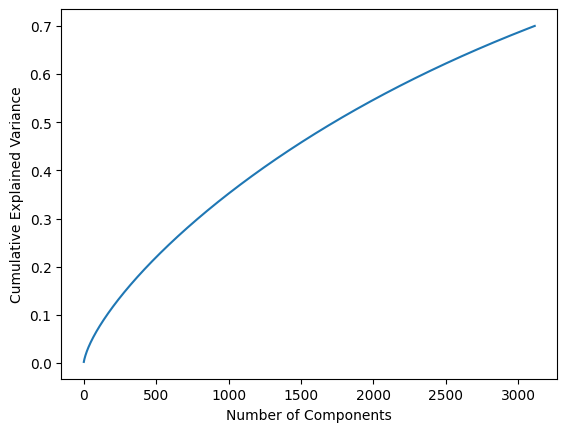

In [53]:
# Plotting cummulative frequency

import numpy as np
import matplotlib.pyplot as plt

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

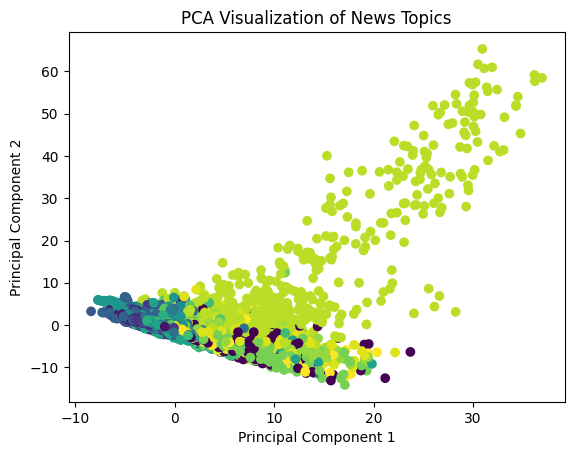

In [54]:
# PCA visualization

import matplotlib.pyplot as plt

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['target'], cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of News Topics")
plt.show()

In [55]:
# Storing pca output

# Converting to a DataFrame
X_pca_df = pd.DataFrame(X_pca)

In [56]:
### COSINE SIMILARITY

# cinverting PCA output to df
import pandas as pd

X_pca_df = pd.DataFrame(X_pca)


In [63]:
import numpy as np
from sklearn.preprocessing import normalize

X = X_pca  # numpy array

# Clean
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Clip (critical)
X = np.clip(X, -1e3, 1e3)

# Normalize
X = normalize(X, norm='l2')

# Remove bad rows
norms = np.linalg.norm(X, axis=1)
X = X[norms > 1e-8]

# Stable cosine similarity
cos_sim = np.dot(X, X.T)

# Remove diagonal
np.fill_diagonal(cos_sim, 0)

In [64]:
# showing similarity between two documents

print("Document 0:\n", df['clean_text'].iloc[0])
print("\nDocument 1:\n", df['clean_text'].iloc[1])

print("\nCosine Similarity:", cos_sim_df.iloc[0, 1])

Document 0:
 mamatha devineni ratnam mrandrewcmuedu subject pen fan reaction organization post office carnegie mellon pittsburgh line nntppostinghost poandrewcmuedu sure bashers pen fan pretty confused lack kind post recent pen massacre devil actually bit puzzled bit relieved however going put end nonpittsburghers relief bit praise pen man killing devil worse thought jagr showed much better regular season stats also lot fun watch playoff bowman let jagr lot fun next couple game since pen going beat pulp jersey anyway disappointed see islander lose final regular season game pen rule

Document 1:
 mblawsonmidwayecnuoknoredu matthew lawson subject highperformance vlb video card summary seek recommendation vlb video card nntppostinghost midwayecnuoknoredu organization engineering computer network university oklahoma norman usa keywords orchid stealth vlb line brother market highperformance video card support vesa local bus ram anyone suggestionsideas diamond stealth pro local bus orchid fa

In [65]:
# Finding most similar documents to a given document

doc_index = 0   # change this to test different documents

similar_docs = np.argsort(cos_sim_df.iloc[doc_index])[::-1]

top_match = similar_docs[0]   # most similar (after removing diagonal)

print("Original Document:\n", df['clean_text'].iloc[doc_index])
print("\nMost Similar Document:\n", df['clean_text'].iloc[top_match])
print("\nSimilarity Score:", cos_sim_df.iloc[doc_index, top_match])

Original Document:
 mamatha devineni ratnam mrandrewcmuedu subject pen fan reaction organization post office carnegie mellon pittsburgh line nntppostinghost poandrewcmuedu sure bashers pen fan pretty confused lack kind post recent pen massacre devil actually bit puzzled bit relieved however going put end nonpittsburghers relief bit praise pen man killing devil worse thought jagr showed much better regular season stats also lot fun watch playoff bowman let jagr lot fun next couple game since pen going beat pulp jersey anyway disappointed see islander lose final regular season game pen rule

Most Similar Document:
 organization penn state university andrew newell tanpsuvmpsuedu subject free moral agency distribution cpxqslmdarksideosrheuoknoredu line article cpxqslmdarksideosrheuoknoredu bilokcforumosrheedu bill conner say deankaflowitz decaycbnewsjcbattcom wrote interested original notion discussing moral free agency god punish person believing person following nature possible person de

In [66]:
# Detecting topic drift ( threshold logic)

threshold = 0.5

if cos_sim_df.iloc[doc_index, top_match] < threshold:
    print("\n⚠️ Topic Drift Detected")
else:
    print("\n✅ Same Topic (No Drift)")


⚠️ Topic Drift Detected


In [68]:
### TRAINING THE MODEL ###

In [69]:
## Importing some libraries

!pip install gensim
import numpy as np
import matplotlib.pyplot as plt
import gensim

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer

from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')

You should consider upgrading via the '/Users/dibbi/myenv/bin/python3 -m pip install --upgrade pip' command.


/Users/dibbi/myenv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[nltk_data] Downloading package punkt to /Users/dibbi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [70]:
## Traing-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [71]:
## Similarity prediction function

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def predict_similarity(X_train_bow, X_test_bow, y_train):
    predictions = []

    print("X_test size:", X_test.shape[0])   # 👈 DEBUG


    for i in range(X_test.shape[0]):   # ✅ FIXED
        sim = cosine_similarity(X_test[i:i+1], X_train)
        best_idx = np.argmax(sim)
        predictions.append(y_train.iloc[best_idx])  # ✅ FIXED

    return predictions

In [76]:
print(type(X_train))

<class 'numpy.ndarray'>


In [72]:
### DIFFERENT VECTORIZATION METHODS

In [80]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score

# ===== LOAD TEXT + LABELS =====
X = df['text']
y = df['target']

# ===== TRAIN TEST SPLIT =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===== CLEAN TEXT =====
X_train = X_train.fillna("").astype(str).str.lower().tolist()
X_test = X_test.fillna("").astype(str).str.lower().tolist()

# ===== VECTORIZATION =====
bow = CountVectorizer(stop_words='english', max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

# ===== SIMILARITY FUNCTION (FAST & CORRECT) =====
def predict_similarity(X_train, X_test, y_train):
    y_train = np.array(y_train)

    # cosine similarity matrix
    sim_matrix = cosine_similarity(X_test, X_train)

    # best match indices
    indices = np.argmax(sim_matrix, axis=1)

    return y_train[indices]

# ===== PREDICTION =====
pred_bow = predict_similarity(X_train_bow, X_test_bow, y_train)

# ===== EVALUATION =====
acc = accuracy_score(y_test, pred_bow)

print("Accuracy:", acc)

Accuracy: 0.7877984084880637


In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

# ===== TF-IDF =====
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ===== PREDICTION =====
pred_tfidf = predict_similarity(X_train_tfidf, X_test_tfidf, y_train)

# ===== ACCURACY =====
acc_tfidf = accuracy_score(y_test, pred_tfidf)

print("TF-IDF Accuracy:", acc_tfidf)

TF-IDF Accuracy: 0.8


In [84]:
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics import accuracy_score

# ===== HASHING VECTORIZER =====
hash_vec = HashingVectorizer(stop_words='english', n_features=5000)

X_train_hash = hash_vec.transform(X_train)
X_test_hash = hash_vec.transform(X_test)

# ===== PREDICTION =====
pred_hash = predict_similarity(X_train_hash, X_test_hash, y_train)

# ===== ACCURACY =====
acc_hash = accuracy_score(y_test, pred_hash)

print("Hashing Vectorizer Accuracy:", acc_hash)

Hashing Vectorizer Accuracy: 0.816710875331565


In [86]:
import numpy as np
from sklearn.preprocessing import normalize
from sklearn.metrics import accuracy_score

# ===== CONVERT TO VECTORS =====
X_train_w2v = np.array([sentence_vector(w2v_model, doc) for doc in X_train_tokens])
X_test_w2v = np.array([sentence_vector(w2v_model, doc) for doc in X_test_tokens])

# ===== CLEAN (VERY IMPORTANT) =====
X_train_w2v = np.nan_to_num(X_train_w2v, nan=0.0, posinf=0.0, neginf=0.0)
X_test_w2v = np.nan_to_num(X_test_w2v, nan=0.0, posinf=0.0, neginf=0.0)

# ===== REMOVE ZERO VECTORS =====
train_norms = np.linalg.norm(X_train_w2v, axis=1)
test_norms = np.linalg.norm(X_test_w2v, axis=1)

X_train_w2v = X_train_w2v[train_norms > 1e-8]
y_train_clean = np.array(y_train)[train_norms > 1e-8]

X_test_w2v = X_test_w2v[test_norms > 1e-8]
y_test_clean = np.array(y_test)[test_norms > 1e-8]

# ===== NORMALIZE =====
X_train_w2v = normalize(X_train_w2v)
X_test_w2v = normalize(X_test_w2v)

# ===== PREDICTION =====
pred_w2v = predict_similarity(X_train_w2v, X_test_w2v, y_train_clean)

# ===== ACCURACY =====
acc_w2v = accuracy_score(y_test_clean, pred_w2v)

print(f"Word2Vec Accuracy: {acc_w2v:.4f}")

Word2Vec Accuracy: 0.4629


/Users/dibbi/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dibbi/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dibbi/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


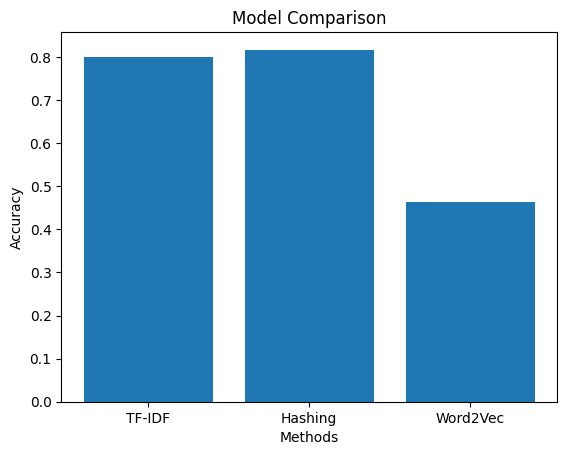

In [89]:
## GRAPH COMPARISON

import matplotlib.pyplot as plt

# ===== SAFE ACCURACY COLLECTION =====
methods = []
accuracies = []

# Add only if variables exist
if 'acc_bow' in globals():
    methods.append('BoW')
    accuracies.append(acc_bow)

if 'acc_tfidf' in globals():
    methods.append('TF-IDF')
    accuracies.append(acc_tfidf)

if 'acc_hash' in globals():
    methods.append('Hashing')
    accuracies.append(acc_hash)

if 'acc_w2v' in globals():
    methods.append('Word2Vec')
    accuracies.append(acc_w2v)

# ===== PLOT =====
plt.figure()
plt.bar(methods, accuracies)
plt.xlabel("Methods")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [93]:
import joblib

# 1. Save the TF-IDF Vectorizer
# Make sure 'tfidf' is the name of your vectorizer variable
try:
    joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
    print("TF-IDF Vectorizer saved successfully!")
except NameError:
    print("Error: The variable 'tfidf' is not defined. Please run the cell where you create the TfidfVectorizer.")

# 2. Save the PCA model (Only if you actually used PCA in your project)
try:
    joblib.dump(pca, 'pca_model.pkl')
    print("PCA model saved successfully!")
except NameError:
    print("Note: 'pca' variable not found. If you didn't use PCA, you can ignore this.")

TF-IDF Vectorizer saved successfully!
PCA model saved successfully!


In [92]:
import pickle

# Save the TF-IDF Vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("TF-IDF Vectorizer saved as tfidf_vectorizer.pkl")

# Save the PCA model
with open('pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)
print("PCA model saved as pca_model.pkl")

TF-IDF Vectorizer saved as tfidf_vectorizer.pkl
PCA model saved as pca_model.pkl
